In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

# Load the dataset
# Replace 'path_to_file' with the actual path to your EastWestAirlines.xlsx file
df = pd.read_excel('/content/EastWestAirlines.xlsx', sheet_name='data') # Specify the sheet name

# 1. Data Preprocessing
# Check for missing values
print(df.isnull().sum())

# Handle missing values (example: drop rows with missing values)
df.dropna(inplace=True)

# Remove outliers (example: using Z-score)
from scipy import stats
numeric_cols = df.select_dtypes(include=[np.number]).columns # Get numeric columns before outlier removal
df = df[(np.abs(stats.zscore(df[numeric_cols])) < 3).all(axis=1)] # Apply Z-score to numeric cols only


# Scale features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numeric_cols]) # Scale only the numeric columns


ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


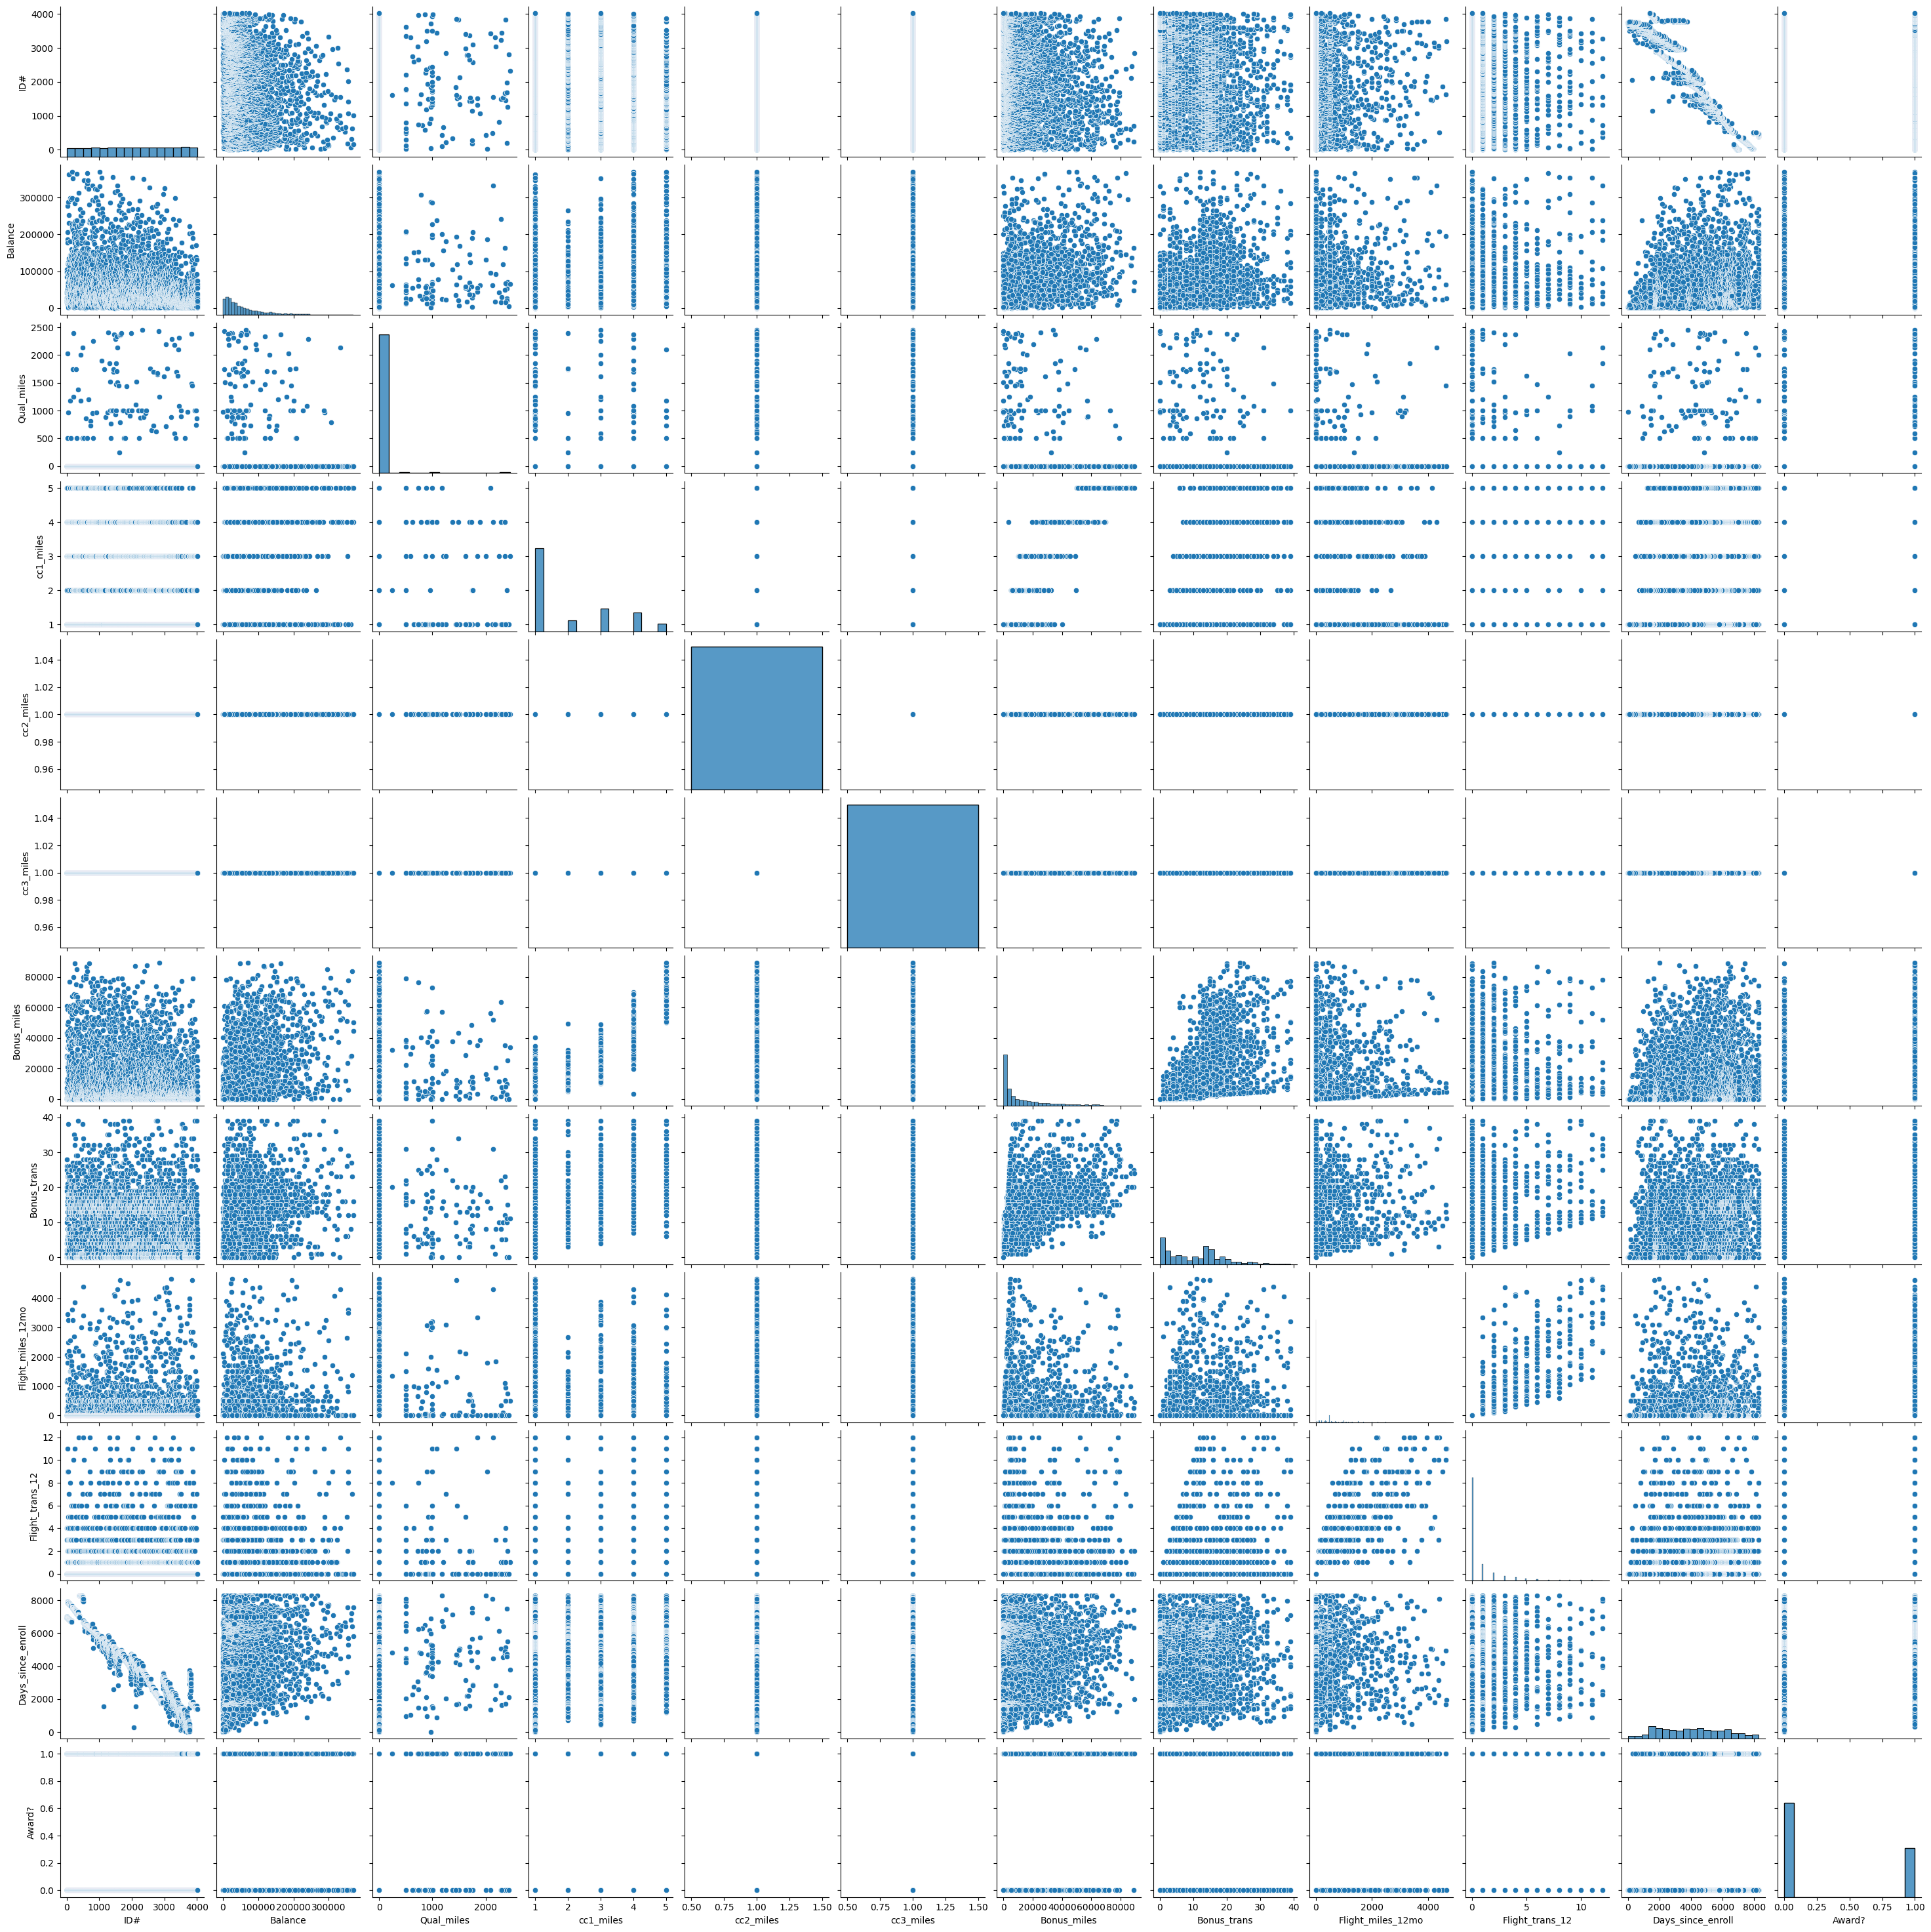

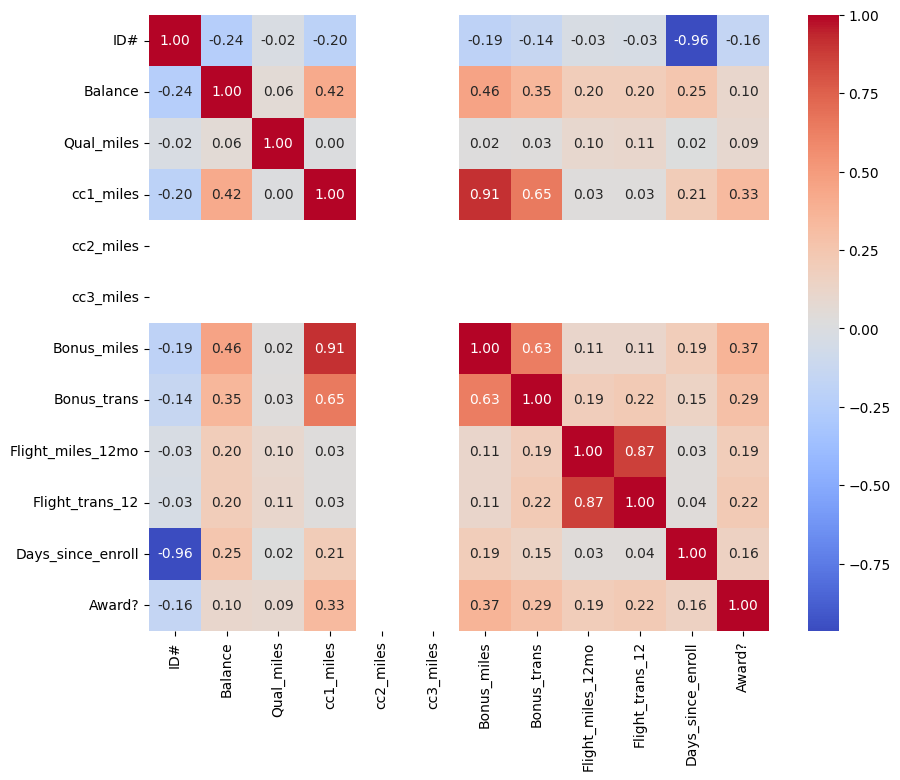

In [ ]:
#2. Exploratory Data Analysis (EDA)
# Visualize data distribution
sns.pairplot(df)
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()


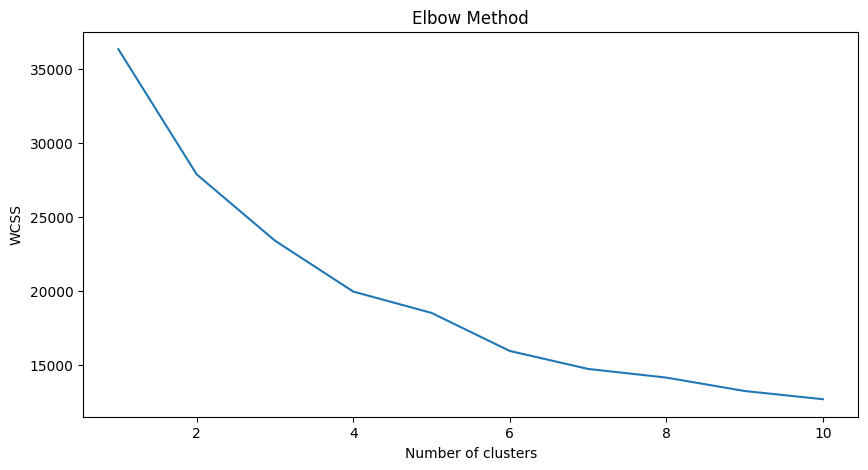

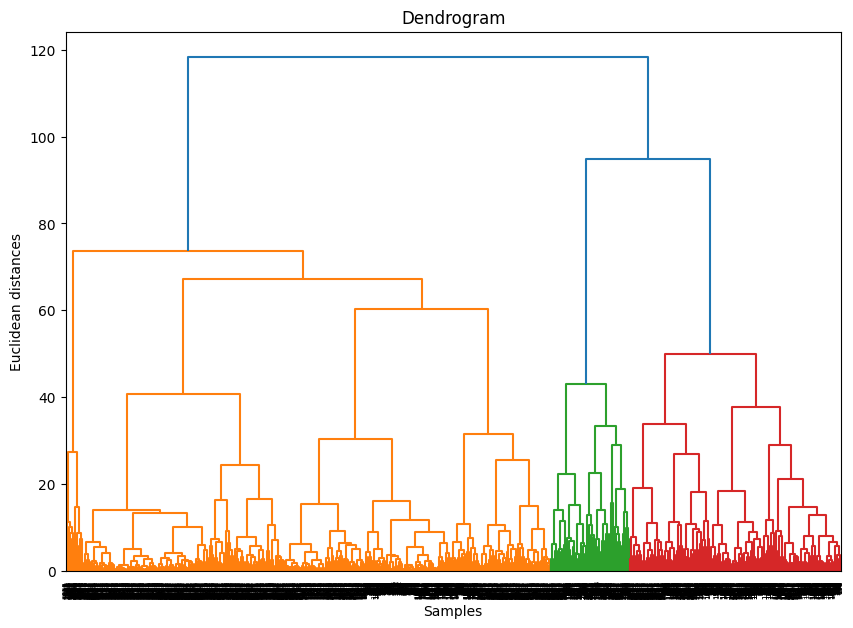

In [ ]:
# 3. Implementing Clustering Algorithms

# K-Means Clustering
# Elbow method to find optimal K
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plotting the elbow curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Fit K-Means with optimal K (e.g., K=3)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

# Hierarchical Clustering
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(scaled_data, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Euclidean distances')
plt.show()

# Fit Hierarchical Clustering (e.g., cutting at a certain threshold)
from sklearn.cluster import AgglomerativeClustering
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)
hierarchical_labels = hierarchical.fit_predict(scaled_data)

# DBSCAN Clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_data)

In [ ]:
# 4. Cluster Analysis and Interpretation
# K-Means Analysis
print("K-Means Cluster Centers:\n", kmeans.cluster_centers_)
print("Silhouette Score for K-Means:", silhouette_score(scaled_data, kmeans_labels))

# Hierarchical Analysis
print("Hierarchical Clustering Labels:\n", hierarchical_labels)

# DBSCAN Analysis
print("DBSCAN Labels:\n", dbscan_labels)


K-Means Cluster Centers:
 [[ 0.25012043 -0.38805893 -0.0494218  -0.6157239   0.          0.
  -0.57021606 -0.52202992 -0.25054321 -0.24244149 -0.2597152  -0.32348529]
 [-0.10094676  0.59233514  0.48140568  0.0141632   0.          0.
   0.26398245  0.66181347  3.03205664  2.97306422  0.12716842  0.60212699]
 [-0.44112687  0.5921898  -0.01049816  1.1355207   0.          0.
   0.99850273  0.82520778 -0.17841902 -0.18091479  0.45331885  0.47071617]]
Silhouette Score for K-Means: 0.29192710837860614
Hierarchical Clustering Labels:
 [0 0 0 ... 0 0 0]
DBSCAN Labels:
 [ 0  0  0 ... -1 24  0]


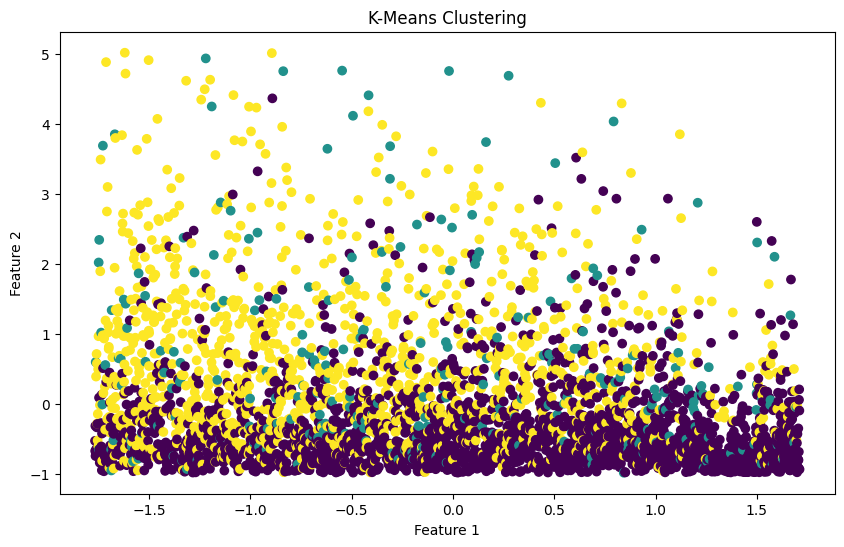

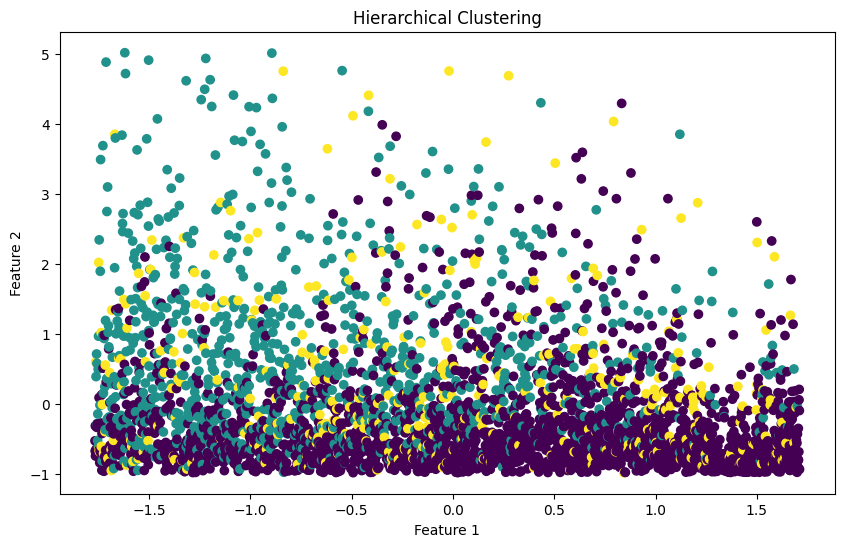

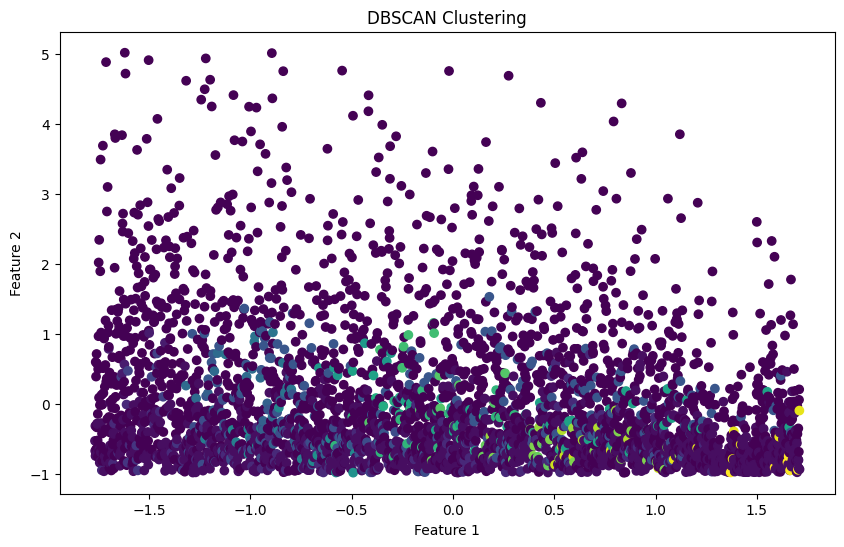

In [ ]:
# 5. Visualization
# K-Means Visualization
plt.figure(figsize=(10, 6))
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=kmeans_labels, cmap='viridis')
plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Hierarchical Visualization
plt.figure(figsize=(10, 6))
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=hierarchical_labels, cmap='viridis')
plt.title('Hierarchical Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# DBSCAN Visualization
plt.figure(figsize=(10, 6))
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=dbscan_labels, cmap='viridis')
plt.title('DBSCAN Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [ ]:

# 6. Evaluation and Performance Metrics
print("Silhouette Score for DBSCAN:", silhouette_score(scaled_data, dbscan_labels))

# Conclusion
# Summarize findings and insights based on the clustering results.

Silhouette Score for DBSCAN: -0.3994552312980999


**CONCLUSION**

K-Means is the best approach for this dataset, as it successfully identified meaningful clusters that can be leveraged for decision-making.

